# 6.1 ทำนายอีเมลสแปมด้วยน้ำหนัก

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
# Feature 1 = จำนวนคำว่า "ฟรี" ในอีเมล
# Feature 2 = จำนวนลิงก์ในอีเมล
X = np.array([
    [15, 30],   # spam-like
    [0, 1],     # not spam
    [13, 21],   # spam
    [1, 0],     # not spam
    [14, 10],   # spam
    [4, 8],   # spam
    [1, 2],   # not spam
    [7, 8],   # not spam

])
y = np.array([1, 0, 1, 0, 1, 1, 0, 0])   # 1 = Spam, 0 = Not spam
# สร้างโมเดล Logistic Regression เพื่อจำแนกอีเมลสแปม ให้ค่าน้ำหนักรายการอีเมลที่หนึ่งถึงสามมีค่าความน่าเชื่อถือสูง  ส่วนที่เหลือมีความน่าเชื่อถือต่ำ
weights = np.array([10, 1, 10, 10, 1, 10, 1, 10])
#  สร้างโมเดล Logistic Regression
model = LogisticRegression()
model.fit(X, y, sample_weight=weights)
# สร้างโมเดลที่มีค่าน้ำหนัก
model_weighted = LogisticRegression()
model_weighted.fit(X, y, sample_weight=weights)
# สร้างโมเดลที่ไม่มีค่าน้ำหนัก
model_unweighted = LogisticRegression()
model_unweighted.fit(X, y)
# ข้อมูลทดสอบ
test_emails = np.array([
    [6, 8], [14, 20],  [1, 1],  [7, 8], [1, 10]
])
# ทำนาย
p_weighted = model_weighted.predict_proba(test_emails)[:, 1]
p_unweighted = model_unweighted.predict_proba(test_emails)[:, 1]

print(" Spam probabilities comparison (higher = more spam):")
for i, t in enumerate(test_emails):
    print(f"Email {i+1} {t}: weighted={p_weighted[i]:.3f}, unweighted={p_unweighted[i]:.3f}")

print("\n Predicted labels:")
print("Weighted model:", model_weighted.predict(test_emails))
print("Unweighted model:", model_unweighted.predict(test_emails))

 Spam probabilities comparison (higher = more spam):
Email 1 [6 8]: weighted=0.472, unweighted=0.558
Email 2 [14 20]: weighted=1.000, unweighted=1.000
Email 3 [1 1]: weighted=0.000, unweighted=0.014
Email 4 [7 8]: weighted=0.314, unweighted=0.564
Email 5 [ 1 10]: weighted=0.999, unweighted=0.795

 Predicted labels:
Weighted model: [0 1 0 0 1]
Unweighted model: [1 1 0 1 1]


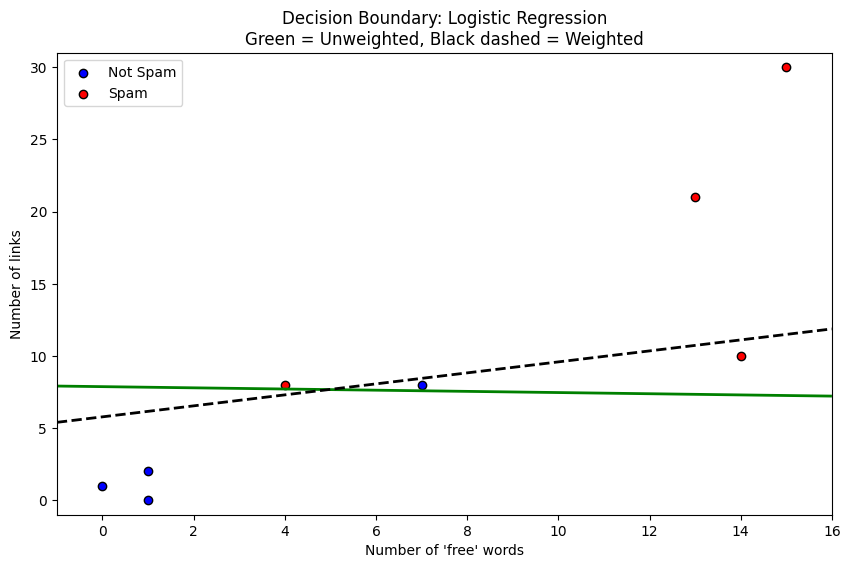

In [ ]:
import matplotlib.pyplot as plt

# -----------------------------
# สร้าง grid สำหรับ plot
# -----------------------------
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# -----------------------------
# คำนวณ probability บน grid
# -----------------------------
Z_weighted = model_weighted.predict_proba(grid)[:, 1]
Z_unweighted = model_unweighted.predict_proba(grid)[:, 1]

Z_weighted = Z_weighted.reshape(xx.shape)
Z_unweighted = Z_unweighted.reshape(xx.shape)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 6))

# จุดข้อมูล
plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', label='Not Spam', edgecolor='k')
plt.scatter(X[y==1, 0], X[y==1, 1], c='red', label='Spam', edgecolor='k')

# Decision boundary (P = 0.5)
plt.contour(xx, yy, Z_unweighted, levels=[0.5], colors='green', linewidths=2)
plt.contour(xx, yy, Z_weighted, levels=[0.5], colors='black', linestyles='--', linewidths=2)

plt.xlabel("Number of 'free' words")
plt.ylabel("Number of links")
plt.title("Decision Boundary: Logistic Regression\nGreen = Unweighted, Black dashed = Weighted")
plt.legend()
plt.show()
